In [ ]:
from keras_facenet import FaceNet
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
import os

data_base_path = 'data/images/'

# Load models
embedder = FaceNet()
detector = MTCNN()

def load_and_detect_face(path: str):
    image = cv2.imread(path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = detector.detect_faces(image_rgb)[0]
    x, y, width, height = result['box']
    x, y = max(0, x), max(0, y)
    face = image_rgb[y:y + height, x:x + width]
    face = cv2.resize(face, (160, 200))
    return face


def get_face_embedding(face_rgb: np.ndarray):
    embedding = embedder.embeddings([face_rgb])[0]
    return embedding

In [ ]:
# Process video and get average embedding
def process_video_and_get_embedding():
    video_path = 'data/images/IMG_7109.mp4'
    cap = cv2.VideoCapture(video_path)

    embeddings = []
    frame_count = 0
    skip_frames = 1

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % skip_frames == 0:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(rgb_frame)

            for result in results:
                x, y, w, h = result['box']
                x, y = max(0, x), max(0, y)
                face = rgb_frame[y:y + h, x:x + w]
                face = cv2.resize(face, (160, 200))
                # save face image
                #cv2.imwrite(f'data/enrollment/face_{frame_count}.jpg', cv2.cvtColor(face, cv2.COLOR_RGB2BGR))

        frame_count += 1

    cap.release()
    cv2.destroyAllWindows()

In [ ]:
enrollment_folder = 'data/enrollment/'
enrollment_files = os.listdir(enrollment_folder)

enrollment_embeddings = []
enrollment_images = []

for file in enrollment_files:
    image_path = os.path.join(enrollment_folder, file)
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_embedding = get_face_embedding(image)
    enrollment_embeddings.append(face_embedding)
    enrollment_images.append(image_path)

In [32]:
# compute threshold based on enrollment data
mean_embedding = np.mean(enrollment_embeddings, axis=0)

distances = np.linalg.norm(enrollment_embeddings - mean_embedding, axis=1)

mean_distance = np.mean(distances)
std_distance = np.std(distances)
threshold = mean_distance + 2 * std_distance

print(f"Adaptive threshold set at: {threshold:.4f}")

Adaptive threshold set at: 0.7269


1/1 [==============================] - 0s 35ms/step
Testing image: Screenshot 2025-04-19 at 16.54.53.png


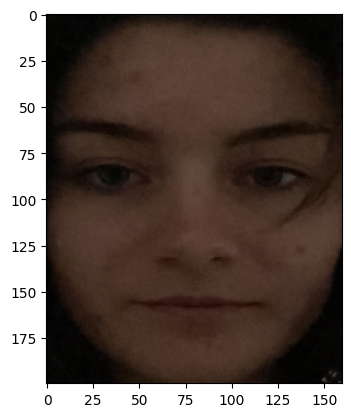

Distance with data/enrollment/face_47.jpg: 0.8116
Distance with data/enrollment/face_90.jpg: 0.7267
Distance with data/enrollment/face_91.jpg: 0.7774
Distance with data/enrollment/face_46.jpg: 0.7954
Distance with data/enrollment/face_78.jpg: 0.9371
Distance with data/enrollment/face_87.jpg: 0.6650
Distance with data/enrollment/face_93.jpg: 0.6750
Distance with data/enrollment/face_92.jpg: 0.7279
Distance with data/enrollment/face_86.jpg: 0.7008
Distance with data/enrollment/face_45.jpg: 0.7824
Distance with data/enrollment/face_96.jpg: 0.8193
Distance with data/enrollment/face_9.jpg: 0.9002
Distance with data/enrollment/face_97.jpg: 0.8409
Distance with data/enrollment/face_83.jpg: 0.7511
Distance with data/enrollment/face_68.jpg: 0.9364
Distance with data/enrollment/face_42.jpg: 0.7096
Distance with data/enrollment/face_95.jpg: 0.8342
Distance with data/enrollment/face_94.jpg: 0.8863
Distance with data/enrollment/face_43.jpg: 0.7556
Distance with data/enrollment/face_117.jpg: 0.6278


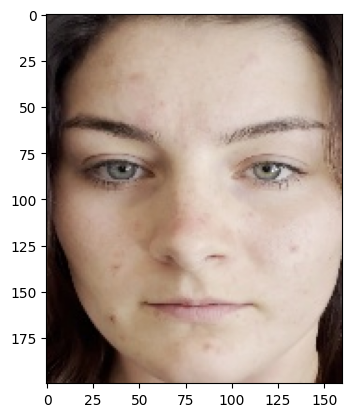

1/1 [==============================] - 0s 33ms/step
Testing image: Screenshot 2025-04-18 at 18.00.30.png


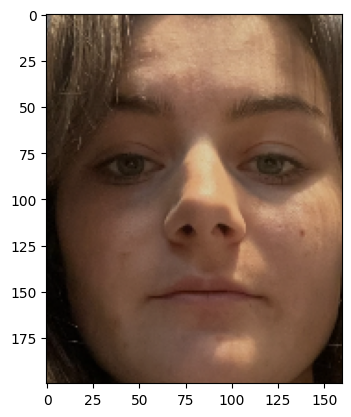

Distance with data/enrollment/face_47.jpg: 0.8021
Distance with data/enrollment/face_90.jpg: 0.8105
Distance with data/enrollment/face_91.jpg: 0.8002
Distance with data/enrollment/face_46.jpg: 0.8093
Distance with data/enrollment/face_78.jpg: 0.9713
Distance with data/enrollment/face_87.jpg: 0.8436
Distance with data/enrollment/face_93.jpg: 0.6899
Distance with data/enrollment/face_92.jpg: 0.7255
Distance with data/enrollment/face_86.jpg: 0.7752
Distance with data/enrollment/face_45.jpg: 0.8061
Distance with data/enrollment/face_96.jpg: 0.7624
Distance with data/enrollment/face_9.jpg: 0.7720
Distance with data/enrollment/face_97.jpg: 0.7422
Distance with data/enrollment/face_83.jpg: 0.8333
Distance with data/enrollment/face_68.jpg: 0.9834
Distance with data/enrollment/face_42.jpg: 0.8044
Distance with data/enrollment/face_95.jpg: 0.7472
Distance with data/enrollment/face_94.jpg: 0.8416
Distance with data/enrollment/face_43.jpg: 0.8223
Distance with data/enrollment/face_117.jpg: 0.7758


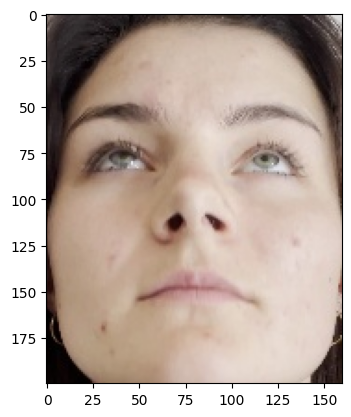

1/1 [==============================] - 0s 36ms/step
Testing image: Screenshot 2025-04-19 at 16.43.38.png


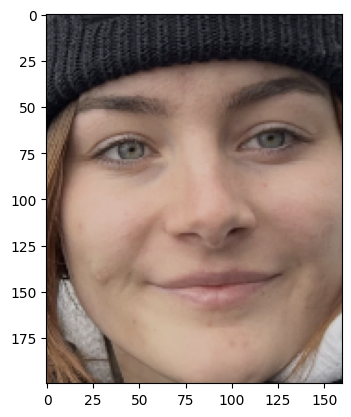

Distance with data/enrollment/face_47.jpg: 1.0199
Distance with data/enrollment/face_90.jpg: 0.8149
Distance with data/enrollment/face_91.jpg: 0.8847
Distance with data/enrollment/face_46.jpg: 1.0130
Distance with data/enrollment/face_78.jpg: 0.9737
Distance with data/enrollment/face_87.jpg: 0.7695
Distance with data/enrollment/face_93.jpg: 0.7927
Distance with data/enrollment/face_92.jpg: 0.8148
Distance with data/enrollment/face_86.jpg: 0.8874
Distance with data/enrollment/face_45.jpg: 0.9790
Distance with data/enrollment/face_96.jpg: 0.8252
Distance with data/enrollment/face_9.jpg: 1.0234
Distance with data/enrollment/face_97.jpg: 0.8618
Distance with data/enrollment/face_83.jpg: 0.9164
Distance with data/enrollment/face_68.jpg: 0.9789
Distance with data/enrollment/face_42.jpg: 0.9333
Distance with data/enrollment/face_95.jpg: 0.8248
Distance with data/enrollment/face_94.jpg: 0.9150
Distance with data/enrollment/face_43.jpg: 0.9404
Distance with data/enrollment/face_117.jpg: 0.7696


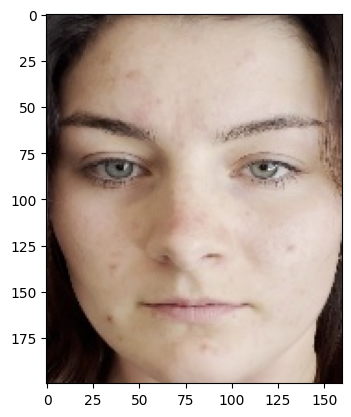

1/1 [==============================] - 0s 33ms/step
Testing image: Screenshot 2025-04-18 at 17.56.16.png


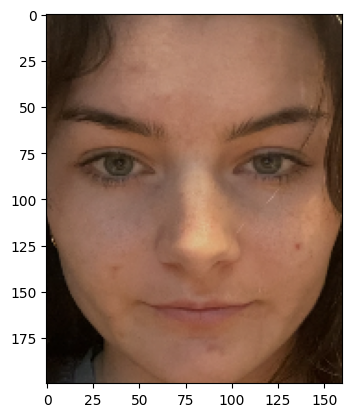

Distance with data/enrollment/face_47.jpg: 0.8655
Distance with data/enrollment/face_90.jpg: 0.7382
Distance with data/enrollment/face_91.jpg: 0.8029
Distance with data/enrollment/face_46.jpg: 0.8383
Distance with data/enrollment/face_78.jpg: 0.9601
Distance with data/enrollment/face_87.jpg: 0.8011
Distance with data/enrollment/face_93.jpg: 0.7915
Distance with data/enrollment/face_92.jpg: 0.7883
Distance with data/enrollment/face_86.jpg: 0.7168
Distance with data/enrollment/face_45.jpg: 0.8383
Distance with data/enrollment/face_96.jpg: 0.8866
Distance with data/enrollment/face_9.jpg: 1.0208
Distance with data/enrollment/face_97.jpg: 0.8965
Distance with data/enrollment/face_83.jpg: 0.8090
Distance with data/enrollment/face_68.jpg: 0.9556
Distance with data/enrollment/face_42.jpg: 0.8188
Distance with data/enrollment/face_95.jpg: 0.8880
Distance with data/enrollment/face_94.jpg: 0.8829
Distance with data/enrollment/face_43.jpg: 0.8487
Distance with data/enrollment/face_117.jpg: 0.7739


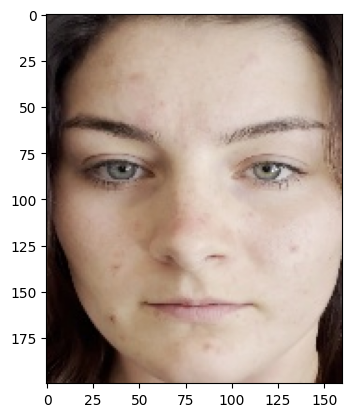

1/1 [==============================] - 0s 38ms/step
Testing image: Screenshot 2025-04-19 at 16.56.03.png


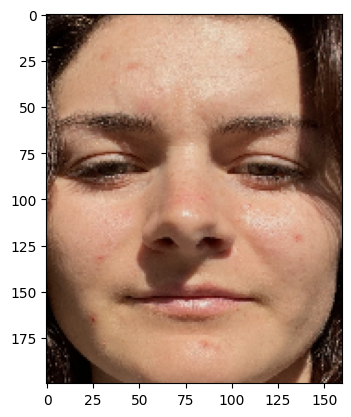

Distance with data/enrollment/face_47.jpg: 0.8875
Distance with data/enrollment/face_90.jpg: 0.8984
Distance with data/enrollment/face_91.jpg: 0.8141
Distance with data/enrollment/face_46.jpg: 0.8893
Distance with data/enrollment/face_78.jpg: 1.0010
Distance with data/enrollment/face_87.jpg: 0.8717
Distance with data/enrollment/face_93.jpg: 0.6974
Distance with data/enrollment/face_92.jpg: 0.7954
Distance with data/enrollment/face_86.jpg: 0.9471
Distance with data/enrollment/face_45.jpg: 0.8537
Distance with data/enrollment/face_96.jpg: 0.7867
Distance with data/enrollment/face_9.jpg: 0.8610
Distance with data/enrollment/face_97.jpg: 0.8037
Distance with data/enrollment/face_83.jpg: 0.9349
Distance with data/enrollment/face_68.jpg: 0.9263
Distance with data/enrollment/face_42.jpg: 0.7558
Distance with data/enrollment/face_95.jpg: 0.7711
Distance with data/enrollment/face_94.jpg: 0.8930
Distance with data/enrollment/face_43.jpg: 0.7369
Distance with data/enrollment/face_117.jpg: 0.6014


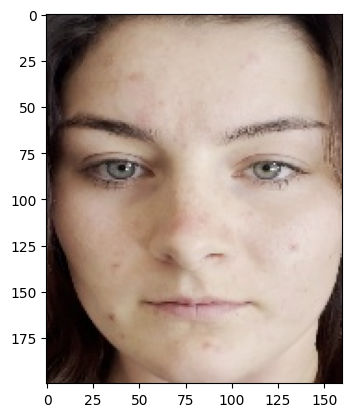

1/1 [==============================] - 0s 35ms/step
Testing image: Screenshot 2025-04-18 at 20.33.27.png


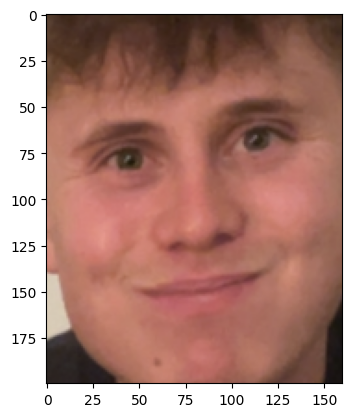

Distance with data/enrollment/face_47.jpg: 1.5764
Distance with data/enrollment/face_90.jpg: 1.5515
Distance with data/enrollment/face_91.jpg: 1.5110
Distance with data/enrollment/face_46.jpg: 1.5584
Distance with data/enrollment/face_78.jpg: 1.4190
Distance with data/enrollment/face_87.jpg: 1.5234
Distance with data/enrollment/face_93.jpg: 1.5460
Distance with data/enrollment/face_92.jpg: 1.5403
Distance with data/enrollment/face_86.jpg: 1.5259
Distance with data/enrollment/face_45.jpg: 1.5756
Distance with data/enrollment/face_96.jpg: 1.5133
Distance with data/enrollment/face_9.jpg: 1.4298
Distance with data/enrollment/face_97.jpg: 1.5208
Distance with data/enrollment/face_83.jpg: 1.5207
Distance with data/enrollment/face_68.jpg: 1.5104
Distance with data/enrollment/face_42.jpg: 1.5470
Distance with data/enrollment/face_95.jpg: 1.5176
Distance with data/enrollment/face_94.jpg: 1.5140
Distance with data/enrollment/face_43.jpg: 1.5397
Distance with data/enrollment/face_117.jpg: 1.5446


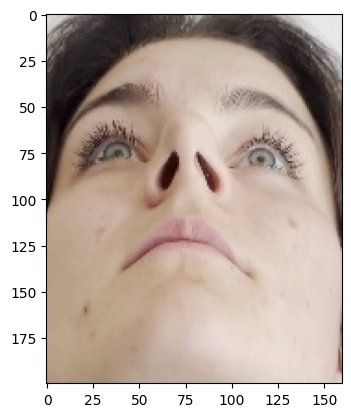

1/1 [==============================] - 0s 35ms/step
Testing image: Screenshot 2025-04-19 at 16.45.25.png


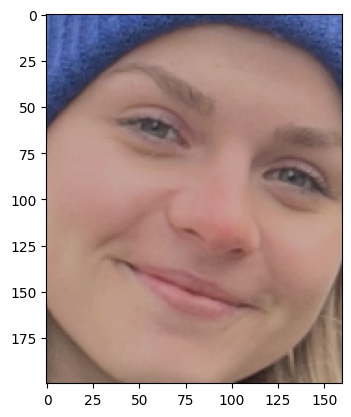

Distance with data/enrollment/face_47.jpg: 1.2498
Distance with data/enrollment/face_90.jpg: 1.2625
Distance with data/enrollment/face_91.jpg: 1.1884
Distance with data/enrollment/face_46.jpg: 1.2311
Distance with data/enrollment/face_78.jpg: 1.2792
Distance with data/enrollment/face_87.jpg: 1.3018
Distance with data/enrollment/face_93.jpg: 1.1850
Distance with data/enrollment/face_92.jpg: 1.1694
Distance with data/enrollment/face_86.jpg: 1.2504
Distance with data/enrollment/face_45.jpg: 1.1970
Distance with data/enrollment/face_96.jpg: 1.1466
Distance with data/enrollment/face_9.jpg: 1.2529
Distance with data/enrollment/face_97.jpg: 1.1341
Distance with data/enrollment/face_83.jpg: 1.2609
Distance with data/enrollment/face_68.jpg: 1.2019
Distance with data/enrollment/face_42.jpg: 1.2131
Distance with data/enrollment/face_95.jpg: 1.0821
Distance with data/enrollment/face_94.jpg: 1.1456
Distance with data/enrollment/face_43.jpg: 1.2079
Distance with data/enrollment/face_117.jpg: 1.2086


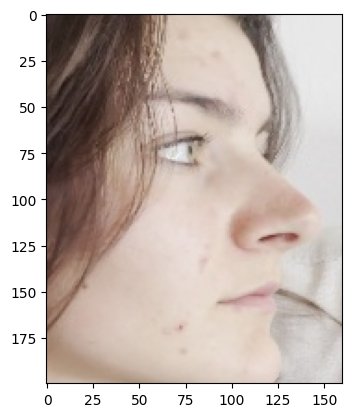

1/1 [==============================] - 0s 37ms/step
Testing image: Screenshot 2025-04-19 at 16.57.36.png


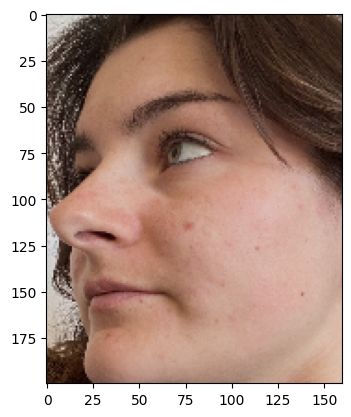

Distance with data/enrollment/face_47.jpg: 0.8250
Distance with data/enrollment/face_90.jpg: 0.8579
Distance with data/enrollment/face_91.jpg: 0.8697
Distance with data/enrollment/face_46.jpg: 0.8041
Distance with data/enrollment/face_78.jpg: 0.8558
Distance with data/enrollment/face_87.jpg: 0.8383
Distance with data/enrollment/face_93.jpg: 0.8071
Distance with data/enrollment/face_92.jpg: 0.8454
Distance with data/enrollment/face_86.jpg: 0.8097
Distance with data/enrollment/face_45.jpg: 0.7971
Distance with data/enrollment/face_96.jpg: 0.8772
Distance with data/enrollment/face_9.jpg: 0.8989
Distance with data/enrollment/face_97.jpg: 0.8740
Distance with data/enrollment/face_83.jpg: 0.7605
Distance with data/enrollment/face_68.jpg: 0.9066
Distance with data/enrollment/face_42.jpg: 0.7745
Distance with data/enrollment/face_95.jpg: 0.9138
Distance with data/enrollment/face_94.jpg: 0.9264
Distance with data/enrollment/face_43.jpg: 0.7703
Distance with data/enrollment/face_117.jpg: 0.6491


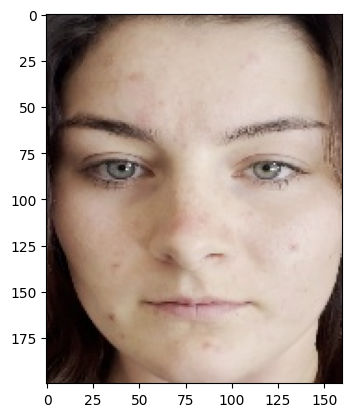

1/1 [==============================] - 0s 35ms/step
Testing image: Screenshot 2025-04-19 at 16.47.25.png


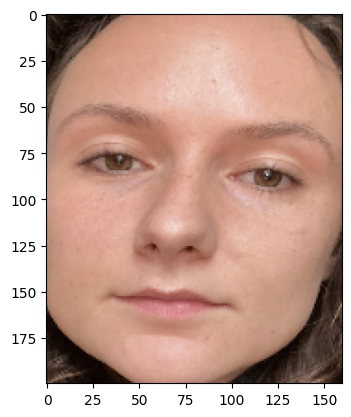

Distance with data/enrollment/face_47.jpg: 1.2120
Distance with data/enrollment/face_90.jpg: 1.2082
Distance with data/enrollment/face_91.jpg: 1.2751
Distance with data/enrollment/face_46.jpg: 1.2101
Distance with data/enrollment/face_78.jpg: 1.3026
Distance with data/enrollment/face_87.jpg: 1.1924
Distance with data/enrollment/face_93.jpg: 1.2235
Distance with data/enrollment/face_92.jpg: 1.1808
Distance with data/enrollment/face_86.jpg: 1.2730
Distance with data/enrollment/face_45.jpg: 1.1988
Distance with data/enrollment/face_96.jpg: 1.2108
Distance with data/enrollment/face_9.jpg: 1.3072
Distance with data/enrollment/face_97.jpg: 1.2459
Distance with data/enrollment/face_83.jpg: 1.1696
Distance with data/enrollment/face_68.jpg: 1.2707
Distance with data/enrollment/face_42.jpg: 1.1582
Distance with data/enrollment/face_95.jpg: 1.2190
Distance with data/enrollment/face_94.jpg: 1.2351
Distance with data/enrollment/face_43.jpg: 1.1756
Distance with data/enrollment/face_117.jpg: 1.1405


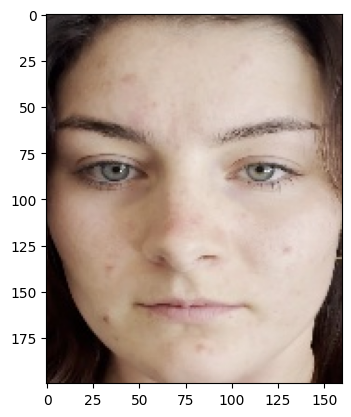

1/1 [==============================] - 0s 36ms/step
Testing image: Screenshot 2025-04-19 at 16.45.20.png


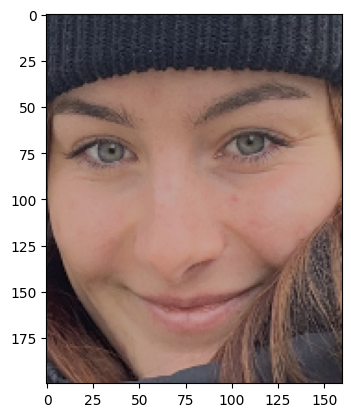

Distance with data/enrollment/face_47.jpg: 1.0685
Distance with data/enrollment/face_90.jpg: 0.8742
Distance with data/enrollment/face_91.jpg: 0.9778
Distance with data/enrollment/face_46.jpg: 1.0643
Distance with data/enrollment/face_78.jpg: 1.0152
Distance with data/enrollment/face_87.jpg: 0.7093
Distance with data/enrollment/face_93.jpg: 0.9369
Distance with data/enrollment/face_92.jpg: 0.9321
Distance with data/enrollment/face_86.jpg: 0.7990
Distance with data/enrollment/face_45.jpg: 1.0466
Distance with data/enrollment/face_96.jpg: 0.9860
Distance with data/enrollment/face_9.jpg: 1.0778
Distance with data/enrollment/face_97.jpg: 1.0233
Distance with data/enrollment/face_83.jpg: 0.7964
Distance with data/enrollment/face_68.jpg: 1.0654
Distance with data/enrollment/face_42.jpg: 1.0052
Distance with data/enrollment/face_95.jpg: 1.0077
Distance with data/enrollment/face_94.jpg: 1.0066
Distance with data/enrollment/face_43.jpg: 1.0399
Distance with data/enrollment/face_117.jpg: 0.8723


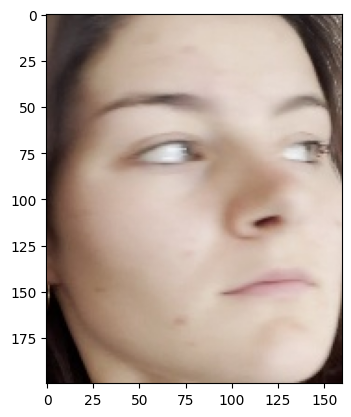

1/1 [==============================] - 0s 36ms/step
Testing image: Screenshot 2025-04-18 at 17.57.27.png


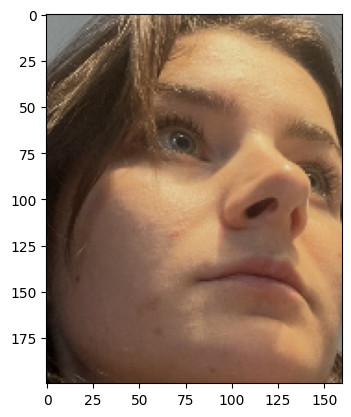

Distance with data/enrollment/face_47.jpg: 1.0759
Distance with data/enrollment/face_90.jpg: 1.1034
Distance with data/enrollment/face_91.jpg: 1.0157
Distance with data/enrollment/face_46.jpg: 1.0759
Distance with data/enrollment/face_78.jpg: 1.1346
Distance with data/enrollment/face_87.jpg: 1.1155
Distance with data/enrollment/face_93.jpg: 0.9167
Distance with data/enrollment/face_92.jpg: 0.9718
Distance with data/enrollment/face_86.jpg: 1.1394
Distance with data/enrollment/face_45.jpg: 1.0649
Distance with data/enrollment/face_96.jpg: 0.9408
Distance with data/enrollment/face_9.jpg: 0.9793
Distance with data/enrollment/face_97.jpg: 0.9087
Distance with data/enrollment/face_83.jpg: 1.1864
Distance with data/enrollment/face_68.jpg: 1.1677
Distance with data/enrollment/face_42.jpg: 1.1027
Distance with data/enrollment/face_95.jpg: 0.9551
Distance with data/enrollment/face_94.jpg: 1.0201
Distance with data/enrollment/face_43.jpg: 1.0798
Distance with data/enrollment/face_117.jpg: 1.1249


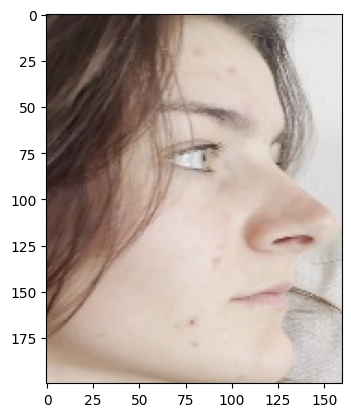

In [40]:
# Process test images and compare with each enrollment image
test_data = 'data/images/testset'
test_files = os.listdir(test_data)

for file in test_files:
    image_path = os.path.join(test_data, file)
    image = load_and_detect_face(image_path)
    test_embedding = get_face_embedding(image)

    print(f"Testing image: {file}")
    plt.imshow(image)
    plt.show()

    distances = []

    # Compare test embedding with each enrollment embedding
    for idx, enrollment_embedding in enumerate(enrollment_embeddings):
        distance = np.linalg.norm(test_embedding - enrollment_embedding)
        distances.append(distance)

        # Load enrollment image for display
        enrollment_image = cv2.imread(enrollment_images[idx])
        enrollment_image_rgb = cv2.cvtColor(enrollment_image, cv2.COLOR_BGR2RGB)

        print(f"Distance with {enrollment_images[idx]}: {distance:.4f}")


    # Find the closest match
    closest_match_idx = np.argmin(distances)
    closest_match_distance = distances[closest_match_idx]
    # display the closest match
    closest_match_image = cv2.imread(enrollment_images[closest_match_idx])
    closest_match_image_rgb = cv2.cvtColor(closest_match_image, cv2.COLOR_BGR2RGB)
    plt.imshow(closest_match_image_rgb)

    if closest_match_distance < threshold:
            print(f"✅ Match found with {enrollment_images[closest_match_idx]} at distance {closest_match_distance:.4f}")
    else:
            print(f"❌ No match with {enrollment_images[closest_match_idx]} at distance {closest_match_distance:.4f}")

    plt.show()
